In [1]:
import os
import sys
import time
import datetime
import pickle
import numpy as np
import pandas as pd

src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import pymc as pm
import pytensor
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

from pytensor.graph.op import Op
from pytensor.link.jax.dispatch import jax_funcify
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap

from efficient_fpt_jax.multi_stage import get_addm_fptd_jax_fast, pad_sacc_array_safely

/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Datasets

In [ ]:
monk_data_1 = pd.read_csv("/users/azhan378/data/azhang/efficient-fpt/empirical_data/behav_table_1.csv")
monk_data_2 = pd.read_csv("/users/azhan378/data/azhang/efficient-fpt/empirical_data/behav_table_2.csv")
monk_data_3 = pd.read_csv("/users/azhan378/data/azhang/efficient-fpt/empirical_data/behav_table_3.csv")

print(f"Monkey 1: {len(monk_data_1)} trials")
print(f"Monkey 2: {len(monk_data_2)} trials")
print(f"Monkey 3: {len(monk_data_3)} trials")

Monkey 1: 587 trials
Monkey 2: 607 trials
Monkey 3: 606 trials


## Global Configuration

In [3]:
sigma    = 1.0   # Fixed noise (unidentifiable with other params)
max_d    = 4    # Max fixation stages (padded saccade dimension)

TRUNC_NUM   = 6    # Series truncation (optimal for JAX/XLA)
N_DRAWS     = 500
N_TUNE      = 500
N_CHAINS    = 4
RANDOM_SEED = 42

## Helper Functions

In [4]:
def preprocess_monkey_data(df, max_d):
    """
    Transform a raw monkey-behaviour DataFrame into model-ready numpy arrays.

    Parameters
    ----------
    df : pd.DataFrame
        Raw behavioural table with columns: trialNum, lVal, rVal,
        firstFixLat, secondFixLat, thirdFixLat, firstIsLeft,
        liftRT, leftChosen.
    max_d : int
        Maximum number of fixation stages (width of padded saccade array).

    Returns
    -------
    dict with keys:
        r1, r2          : left / right value per trial
        rt              : reaction time relative to first fixation onset
        choice          : +1 (left chosen) / -1 (right chosen)
        flag_data       : 0 if first fixation is left, 1 if right
        sacc            : (n_trials, max_d) padded saccade-onset array
        length_data     : number of fixations per trial (2 or 3)
    """
    DATA_TYPE = np.float64
    df = df.sort_values(by='trialNum', ascending=True)

    r1 = df['lVal'].to_numpy(dtype=DATA_TYPE)
    r2 = df['rVal'].to_numpy(dtype=DATA_TYPE)

    third_present = df['thirdFixLat'].notna().to_numpy()
    length_data = np.where(third_present, 3, 2).astype(np.int32)

    t0 = df["firstFixLat"].to_numpy(dtype=DATA_TYPE)
    t1 = df["secondFixLat"].to_numpy(dtype=DATA_TYPE)
    t2 = df["thirdFixLat"].fillna(0).to_numpy(dtype=DATA_TYPE)

    sacc = np.zeros((len(df), max_d), dtype=DATA_TYPE)
    sacc[:, 0] = 0.0
    sacc[:, 1] = t1 - t0
    sacc[third_present, 2] = t2[third_present] - t0[third_present]

    first_is_left = df['firstIsLeft'].to_numpy().astype(int)
    flag_data = np.where(first_is_left == 1, 0, 1).astype(np.int32)

    rt_raw = df["liftRT"].to_numpy(dtype=DATA_TYPE)
    rt = rt_raw - t0

    left_chosen = df["leftChosen"].to_numpy().astype(int)
    choice = np.where(left_chosen == 1, 1.0, -1.0).astype(np.int32)

    return dict(r1=r1, r2=r2, rt=rt, choice=choice,
                flag_data=flag_data, sacc=sacc, length_data=length_data)

In [5]:
def make_jax_arrays(data, max_d):
    """
    Convert preprocessed numpy dict to JAX arrays and pre-compute
    safe saccade arrays (prevents NaN gradients at boundary).

    Parameters
    ----------
    data  : dict returned by preprocess_monkey_data
    max_d : int  (must match the value used during preprocessing)

    Returns
    -------
    dict of JAX arrays: rt, choice, d, r1, r2, flag, sacc_safe
    """
    jax_sacc = jnp.array(data['sacc'])
    jax_d    = jnp.array(data['length_data'])
    jax_sacc_safe = vmap(
        lambda s, d: pad_sacc_array_safely(s, d, max_d)
    )(jax_sacc, jax_d)

    return dict(
        rt       = jnp.array(data['rt']),
        choice   = jnp.array(data['choice']),
        d        = jax_d,
        r1       = jnp.array(data['r1']),
        r2       = jnp.array(data['r2']),
        flag     = jnp.array(data['flag_data']),
        sacc_safe= jax_sacc_safe,
    )

## Dataset-Agnostic JAX Likelihood Helpers

In [6]:
def compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d):
    """
    Compute the alternating drift array for a single trial.

    flag=0 (first fixation left):  [mu1, mu2, mu1, mu2, ...]
    flag=1 (first fixation right): [mu2, mu1, mu2, mu1, ...]
    """
    mu1 = kappa * (r1 - eta * r2)
    mu2 = kappa * (eta * r1 - r2)
    indices = jnp.arange(max_d)
    return jnp.where((indices % 2) == flag, mu1, mu2)


def jax_loglik_single(rt, choice, d, r1, r2, flag, sacc_safe,
                      eta, kappa, a, b, x0, sigma, max_d, trunc_num):
    """Log-likelihood for a single trial."""
    mu_array = compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d)
    fptd = get_addm_fptd_jax_fast(
        rt, d, mu_array, sacc_safe, sigma, a, b, x0, choice,
        order=30, trunc_num=trunc_num, safe_sacc=sacc_safe
    )
    return jnp.log(jnp.maximum(fptd, 1e-30))

In [7]:
def make_jax_likelihood(jax_data, sigma, max_d, trunc_num):
    """
    Build and JIT-compile JAX log-likelihood and gradient functions
    closed over a specific dataset.

    Parameters
    ----------
    jax_data  : dict returned by make_jax_arrays
    sigma     : float  noise parameter (fixed)
    max_d     : int    saccade array width
    trunc_num : int    series truncation number

    Returns
    -------
    loglik_jit   : jit-compiled total log-likelihood (eta, kappa, a, b, x0) -> scalar
    grad_loglik  : jit-compiled gradient tuple     (eta, kappa, a, b, x0) -> 5-tuple
    """
    def loglik_batch(eta, kappa, a, b, x0):
        per_trial = vmap(
            lambda rt, choice, d, r1, r2, flag, sacc_safe: jax_loglik_single(
                rt, choice, d, r1, r2, flag, sacc_safe,
                eta, kappa, a, b, x0, sigma, max_d, trunc_num
            )
        )
        logliks = per_trial(
            jax_data['rt'], jax_data['choice'], jax_data['d'],
            jax_data['r1'], jax_data['r2'], jax_data['flag'], jax_data['sacc_safe']
        )
        return jnp.sum(logliks)

    loglik_jit  = jit(loglik_batch)
    grad_loglik = jit(grad(loglik_batch, argnums=(0, 1, 2, 3, 4)))
    return loglik_jit, grad_loglik

## PyTensor Custom Ops (dataset-agnostic)

In [8]:
class LogLikeJAX(Op):
    """PyTensor Op wrapping a JAX likelihood with analytic gradients."""
    itypes = [pt.dvector]
    otypes = [pt.dscalar]

    def __init__(self, loglik_fn, grad_fn):
        self.loglik_fn = loglik_fn
        self.grad_fn   = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        outputs[0][0] = np.array(float(self.loglik_fn(eta, kappa, a, b, x0)),
                                 dtype="float64")

    def grad(self, inputs, output_grads):
        (theta,)  = inputs
        (g_out,)  = output_grads
        grads = LogLikeJAXGrad(self.grad_fn)(theta)
        return [g_out * grads]


class LogLikeJAXGrad(Op):
    """Gradient Op for LogLikeJAX."""
    itypes = [pt.dvector]
    otypes = [pt.dvector]

    def __init__(self, grad_fn):
        self.grad_fn = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        grads = self.grad_fn(eta, kappa, a, b, x0)
        outputs[0][0] = np.array([float(g) for g in grads], dtype="float64")


@jax_funcify.register(LogLikeJAX)
def jax_funcify_LogLikeJAX(op, **kwargs):
    loglik_fn = op.loglik_fn
    def loglik_jax(theta):
        eta, kappa, a, b, x0 = theta[0], theta[1], theta[2], theta[3], theta[4]
        return loglik_fn(eta, kappa, a, b, x0)
    return loglik_jax


@jax_funcify.register(LogLikeJAXGrad)
def jax_funcify_LogLikeJAXGrad(op, **kwargs):
    grad_fn = op.grad_fn
    def grad_jax(theta):
        eta, kappa, a, b, x0 = theta[0], theta[1], theta[2], theta[3], theta[4]
        return jnp.stack(grad_fn(eta, kappa, a, b, x0))
    return grad_jax

In [9]:
def make_pymc_model(loglike_op, M):
    """
    Construct a PyMC model with the custom JAX likelihood.

    Parameters
    ----------
    loglike_op : LogLikeJAX instance bound to a specific dataset
    M          : float  max observed RT (used to bound the collapse rate b)

    Returns
    -------
    pm.Model
    """
    with pm.Model() as model:
        eta     = pm.Beta("eta",   alpha=2.0, beta=2.0)
        kappa   = pm.Gamma("kappa", alpha=2.0, beta=4.0)
        a_param = pm.Gamma("a",     alpha=4.0, beta=2.0)

        b_raw   = pm.Beta("b_raw", alpha=2.0, beta=2.0)
        b_param = pm.Deterministic("b", b_raw * a_param / M * 0.95)

        x0_raw  = pm.Beta("x0_raw", alpha=2.0, beta=2.0)
        x0_param= pm.Deterministic("x0", -a_param + 2.0 * a_param * x0_raw)

        theta = pt.stack([eta, kappa, a_param, b_param, x0_param])
        pm.Potential("loglik", loglike_op(theta))
    return model

---
# Monkey 1

In [10]:
data_1     = preprocess_monkey_data(monk_data_1, max_d)
jax_data_1 = make_jax_arrays(data_1, max_d)

print(f"Monkey 1 | trials: {len(data_1['rt'])}, max RT: {data_1['rt'].max():.4f}")
print(f"JAX devices: {jax.devices()}")

Monkey 1 | trials: 587, max RT: 1.3751
JAX devices: [CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


In [11]:
loglik_1, grad_1 = make_jax_likelihood(jax_data_1, sigma, max_d, TRUNC_NUM)

print("Warming up JIT for Monkey 1...")
t0_ = time.time()
ll_test_1 = loglik_1(0.7, 0.5, 2.0, 0.3, -0.2)
_          = grad_1(0.7, 0.5, 2.0, 0.3, -0.2)
print(f"JIT warm-up: {time.time()-t0_:.1f}s  |  ll={float(ll_test_1):.4f}")

op_1    = LogLikeJAX(loglik_1, grad_1)
model_1 = make_pymc_model(op_1, float(np.max(data_1['rt'])))
print("Model 1 built.", model_1.point_logps())

Warming up JIT for Monkey 1...
JIT warm-up: 13.2s  |  ll=-582.9877


/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Model 1 built. {'eta': np.float64(-0.98), 'kappa': np.float64(-0.61), 'a': np.float64(-0.25), 'b_raw': np.float64(-0.98), 'x0_raw': np.float64(-0.98), 'loglik': np.float64(-257.1)}


In [12]:
print(f"Sampling Monkey 1 | {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")
print(f"Started: {datetime.datetime.now().strftime('%H:%M:%S')}")

with model_1:
    t_start = time.perf_counter()
    trace_1 = pm.sample(
        draws=N_DRAWS, tune=N_TUNE, chains=N_CHAINS,
        nuts_sampler="numpyro",
        random_seed=RANDOM_SEED,
        progressbar=True,
        return_inferencedata=True,
    )
    t_sample_1 = time.perf_counter() - t_start

print(f"Finished: {datetime.datetime.now().strftime('%H:%M:%S')}")
print(f"Total: {t_sample_1:.1f}s")

Sampling Monkey 1 | 500 draws, 500 tune, 4 chains
Started: 14:34:47


Compiling.. :   0%|          | 0/1000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/1000 [00:21<?, ?it/s]


Running chain 0:   5%|▌         | 50/1000 [00:39<05:41,  2.78it/s]


Running chain 0:  10%|█         | 100/1000 [01:16<08:42,  1.72it/s]


Running chain 0:  20%|██        | 200/1000 [01:28<03:32,  3.76it/s]

Running chain 0:  25%|██▌       | 250/1000 [01:31<02:25,  5.16it/s]



Running chain 0:  30%|███       | 300/1000 [01:35<01:49,  6.38it/s]


Running chain 0:  35%|███▌      | 350/1000 [01:39<01:25,  7.58it/s]


Running chain 0:  40%|████      | 400/1000 [01:43<01:06,  8.98it/s]


Running chain 0:  45%|████▌     | 450/1000 [01:46<00:54, 10.14it/s]


Running chain 0:  50%|█████     | 500/1000 [01:51<00:48, 10.28it/s]


Running chain 0:  55%|█████▌    | 550/1000 [01:55<00:41, 10.73it/s]


Running chain 0:  60%|██████    | 600/1000 [01:59<00:36, 11.10it/s]


Running chain 0:  65%|██████▌   | 650/1000 [02:03<00:30, 11.46it/s]


Running chain 0:  70%|███████   | 700/100

Finished: 14:37:26
Total: 159.1s


=== Monkey 1 Diagnostics ===
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta    0.015  0.010   0.001    0.033      0.000    0.000    1752.0     902.0   
kappa  1.159  0.040   1.083    1.232      0.001    0.001    1150.0    1397.0   
a      3.008  0.085   2.848    3.166      0.002    0.002    1203.0    1277.0   
b      2.068  0.059   1.956    2.178      0.002    0.001    1203.0    1398.0   
x0     0.055  0.034  -0.010    0.119      0.001    0.001    1875.0    1223.0   

       r_hat  
eta      1.0  
kappa    1.0  
a        1.0  
b        1.0  
x0       1.0  


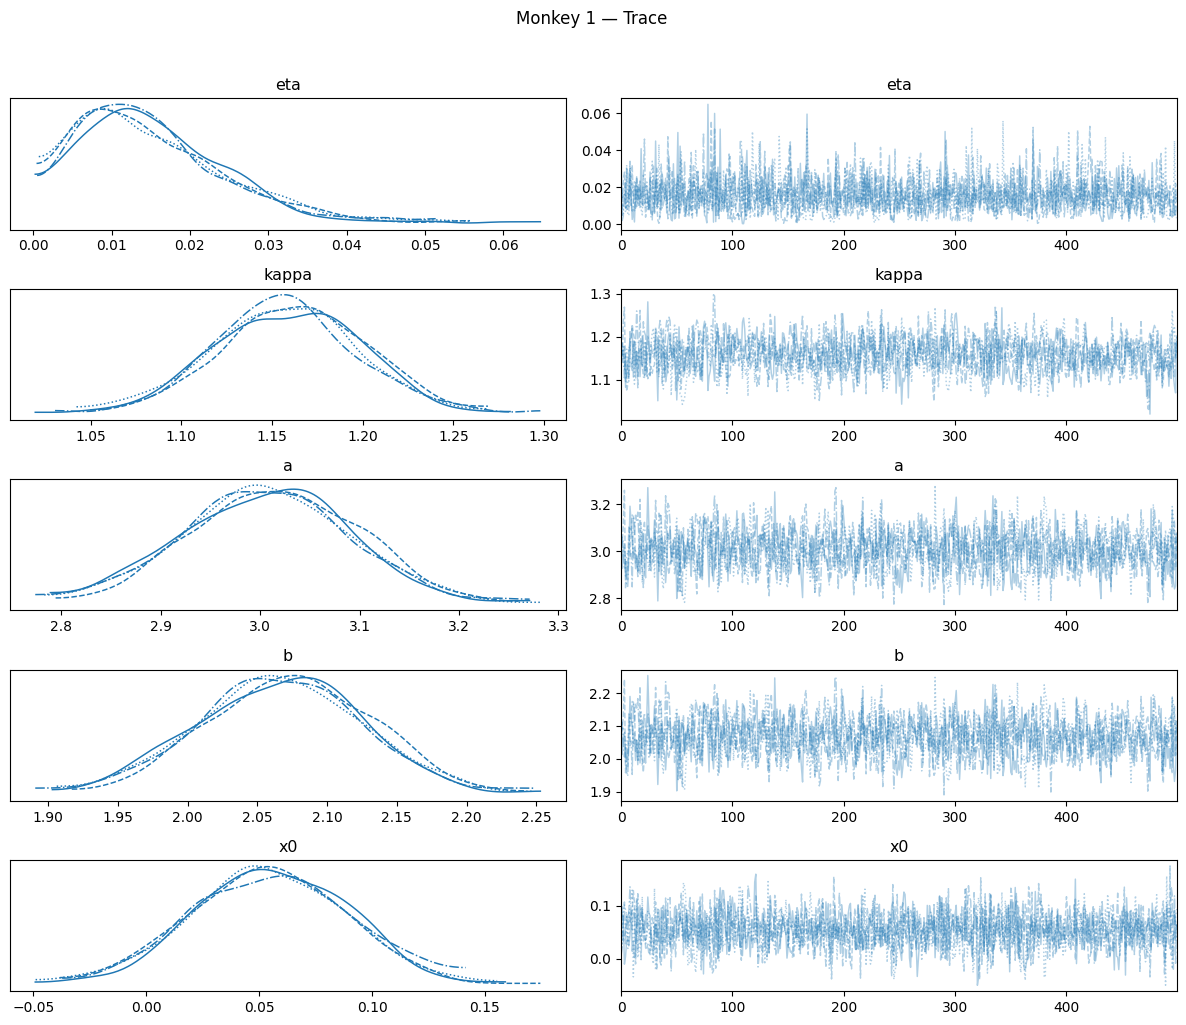

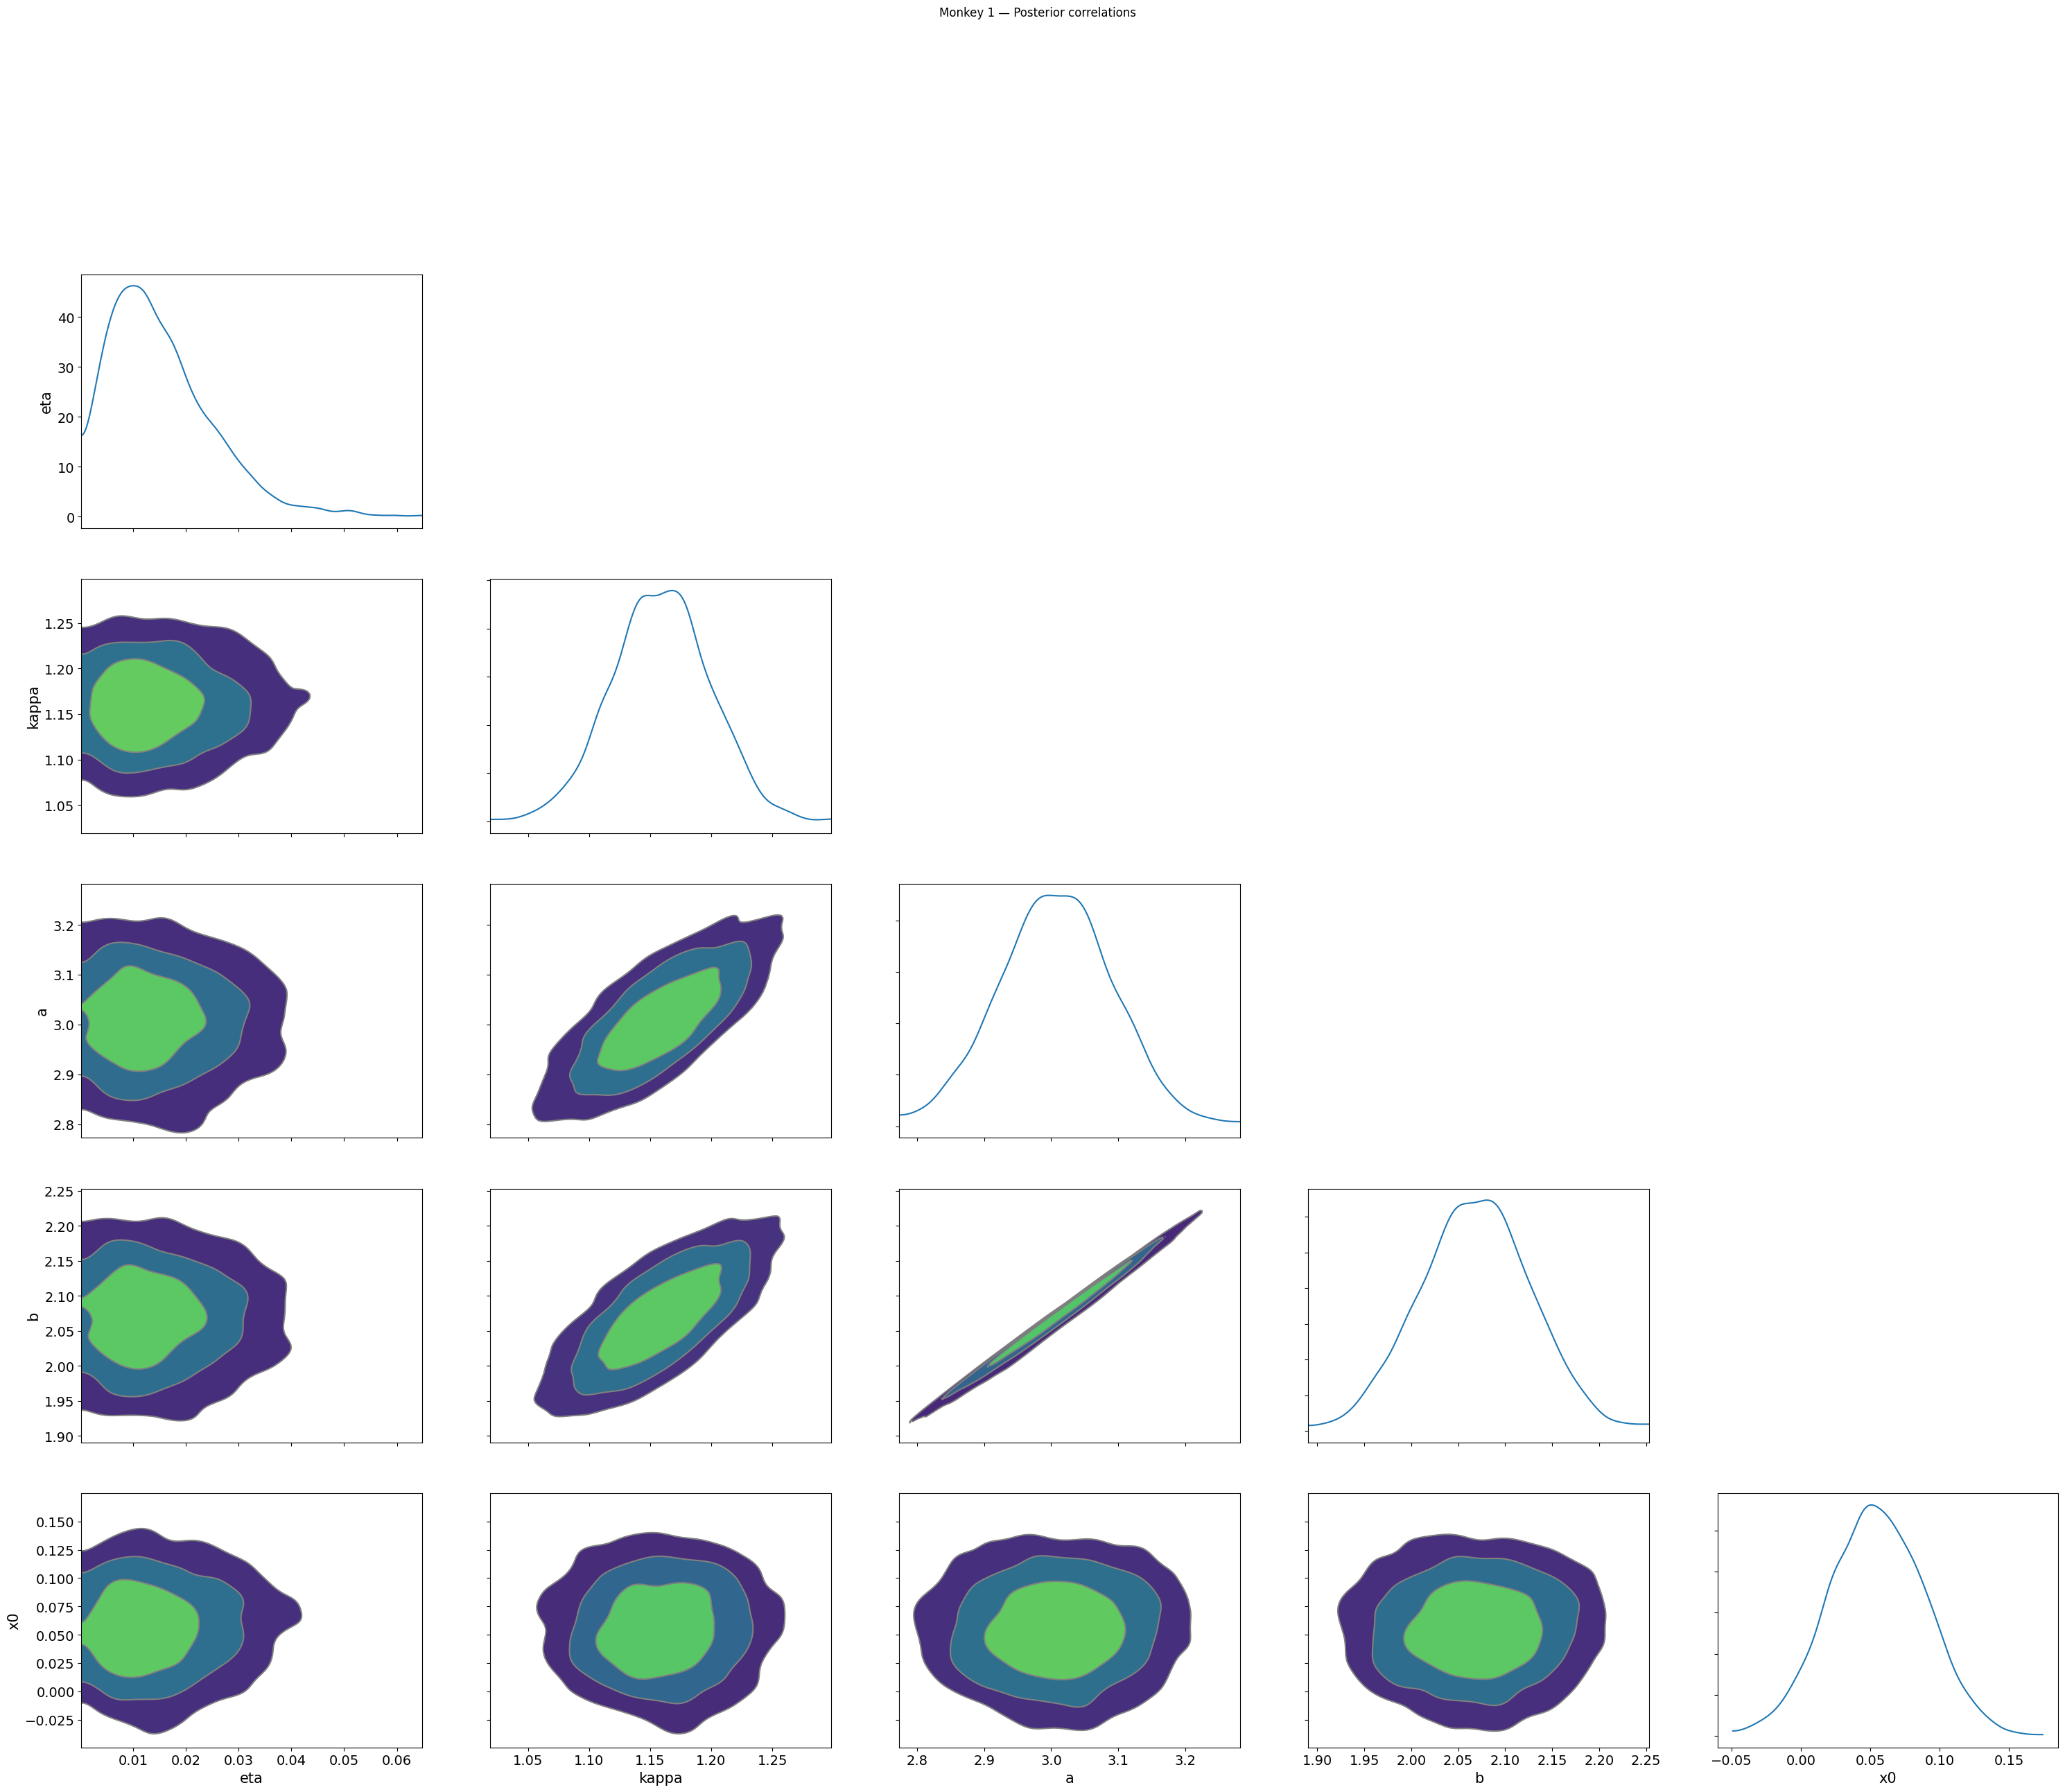

In [13]:
params = ['eta', 'kappa', 'a', 'b', 'x0']
print("=== Monkey 1 Diagnostics ===")
print(az.summary(trace_1, var_names=params))

az.plot_trace(trace_1, var_names=params)
plt.suptitle("Monkey 1 — Trace", y=1.02)
plt.tight_layout()
plt.show()

az.plot_pair(trace_1, var_names=params, kind='kde', marginals=True)
plt.suptitle("Monkey 1 — Posterior correlations", y=1.02)
plt.show()

---
# Monkey 2

In [14]:
data_2     = preprocess_monkey_data(monk_data_2, max_d)
jax_data_2 = make_jax_arrays(data_2, max_d)

print(f"Monkey 2 | trials: {len(data_2['rt'])}, max RT: {data_2['rt'].max():.4f}")

Monkey 2 | trials: 607, max RT: 3.7460


In [15]:
loglik_2, grad_2 = make_jax_likelihood(jax_data_2, sigma, max_d, TRUNC_NUM)

print("Warming up JIT for Monkey 2...")
t0_ = time.time()
ll_test_2 = loglik_2(0.7, 0.5, 2.0, 0.3, -0.2)
_          = grad_2(0.7, 0.5, 2.0, 0.3, -0.2)
print(f"JIT warm-up: {time.time()-t0_:.1f}s  |  ll={float(ll_test_2):.4f}")

op_2    = LogLikeJAX(loglik_2, grad_2)
model_2 = make_pymc_model(op_2, float(np.max(data_2['rt'])))
print("Model 2 built.", model_2.point_logps())

Warming up JIT for Monkey 2...
JIT warm-up: 13.6s  |  ll=-675.4189
Model 2 built. {'eta': np.float64(-0.98), 'kappa': np.float64(-0.61), 'a': np.float64(-0.25), 'b_raw': np.float64(-0.98), 'x0_raw': np.float64(-0.98), 'loglik': np.float64(-627.56)}


In [16]:
print(f"Sampling Monkey 2 | {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")
print(f"Started: {datetime.datetime.now().strftime('%H:%M:%S')}")

with model_2:
    t_start = time.perf_counter()
    trace_2 = pm.sample(
        draws=N_DRAWS, tune=N_TUNE, chains=N_CHAINS,
        nuts_sampler="numpyro",
        random_seed=RANDOM_SEED,
        progressbar=True,
        return_inferencedata=True,
    )
    t_sample_2 = time.perf_counter() - t_start

print(f"Finished: {datetime.datetime.now().strftime('%H:%M:%S')}")
print(f"Total: {t_sample_2:.1f}s")

Sampling Monkey 2 | 500 draws, 500 tune, 4 chains
Started: 14:38:54


Compiling.. :   0%|          | 0/1000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/1000 [00:21<?, ?it/s]





Running chain 0:   5%|▌         | 50/1000 [00:52<09:47,  1.62it/s]



Running chain 0:  10%|█         | 100/1000 [01:27<10:04,  1.49it/s]



Running chain 0:  15%|█▌        | 150/1000 [01:41<06:59,  2.03it/s]


Running chain 0:  25%|██▌       | 250/1000 [01:54<03:19,  3.76it/s]







Running chain 0:  30%|███       | 300/1000 [02:12<03:30,  3.32it/s]





Running chain 0:  35%|███▌      | 350/1000 [02:24<03:02,  3.56it/s]


Running chain 0:  45%|████▌     | 450/1000 [02:38<01:52,  4.89it/s]








Running chain 0:  50%|█████     | 500/1000 [02:57<02:08,  3.88it/s]


Running chain 0:  55%|█████▌    | 550/1000 [03:06<01:46,  4.23it/s]





Running chain 0:  60%|██████    | 600/1000 [03:14<01:23,  4.77it/s]

Running chain 0:  65%|██████▌   | 650/1000 [03:22<01:07,  5.15it/s]

Running chain 0:  70%|███████   | 700/1000 [03:31<00:58,  5.16it/s]

Running chain 1: 100%|

Finished: 14:43:15
Total: 261.3s


=== Monkey 2 Diagnostics ===
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta    0.016  0.011   0.001    0.036      0.000    0.000    1092.0     868.0   
kappa  1.250  0.042   1.171    1.329      0.002    0.001     648.0     643.0   
a      1.949  0.051   1.845    2.040      0.002    0.001     566.0     791.0   
b      0.452  0.016   0.424    0.486      0.001    0.000     584.0     730.0   
x0     0.038  0.030  -0.017    0.094      0.001    0.001    1204.0    1129.0   

       r_hat  
eta      1.0  
kappa    1.0  
a        1.0  
b        1.0  
x0       1.0  


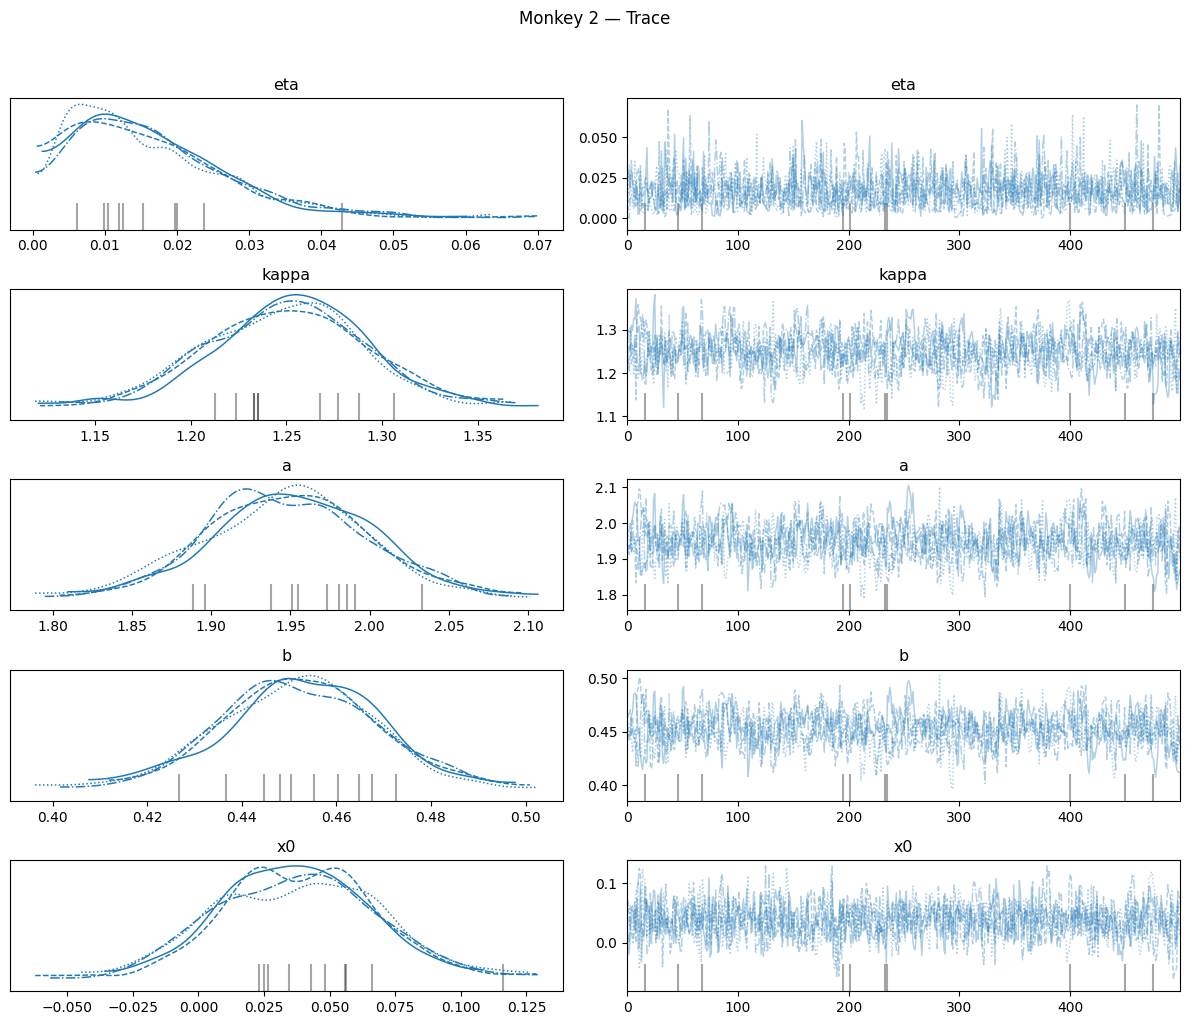

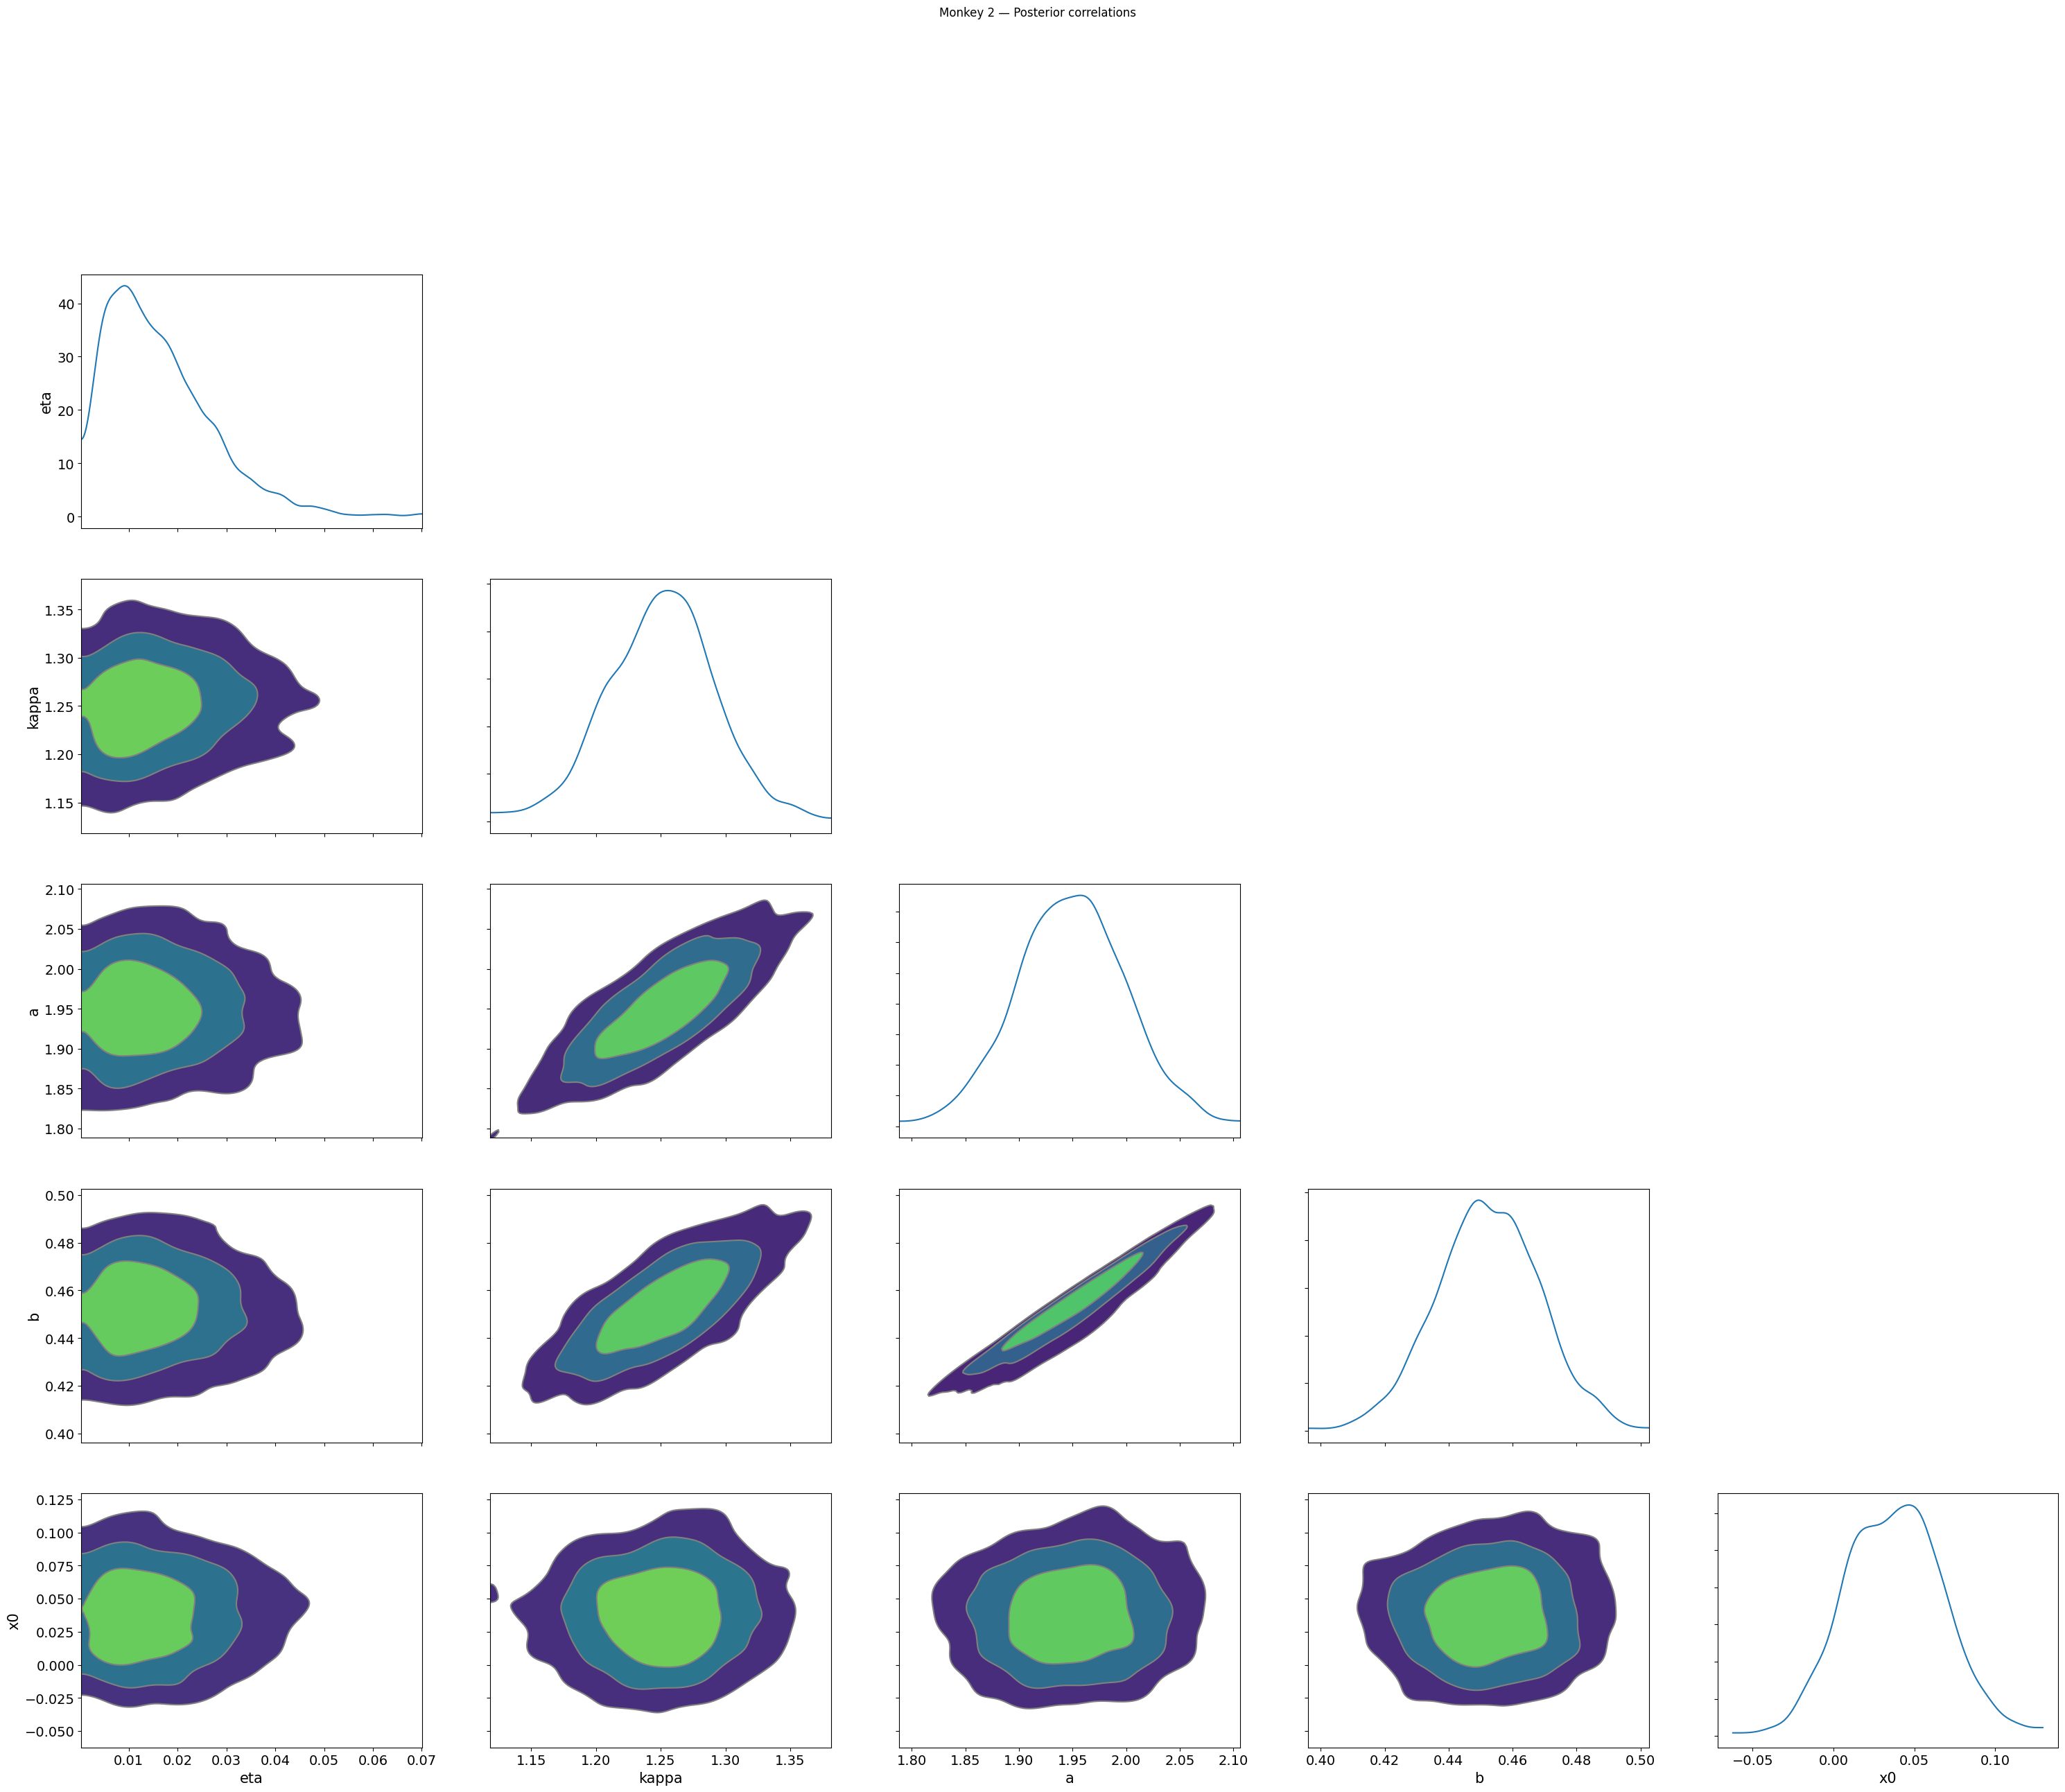

In [17]:
print("=== Monkey 2 Diagnostics ===")
print(az.summary(trace_2, var_names=params))

az.plot_trace(trace_2, var_names=params)
plt.suptitle("Monkey 2 — Trace", y=1.02)
plt.tight_layout()
plt.show()

az.plot_pair(trace_2, var_names=params, kind='kde', marginals=True)
plt.suptitle("Monkey 2 — Posterior correlations", y=1.02)
plt.show()

---
# Monkey 3

In [18]:
data_3     = preprocess_monkey_data(monk_data_3, max_d)
jax_data_3 = make_jax_arrays(data_3, max_d)

print(f"Monkey 3 | trials: {len(data_3['rt'])}, max RT: {data_3['rt'].max():.4f}")

Monkey 3 | trials: 606, max RT: 1.6633


In [19]:
loglik_3, grad_3 = make_jax_likelihood(jax_data_3, sigma, max_d, TRUNC_NUM)

print("Warming up JIT for Monkey 3...")
t0_ = time.time()
ll_test_3 = loglik_3(0.7, 0.5, 2.0, 0.3, -0.2)
_          = grad_3(0.7, 0.5, 2.0, 0.3, -0.2)
print(f"JIT warm-up: {time.time()-t0_:.1f}s  |  ll={float(ll_test_3):.4f}")

op_3    = LogLikeJAX(loglik_3, grad_3)
model_3 = make_pymc_model(op_3, float(np.max(data_3['rt'])))
print("Model 3 built.", model_3.point_logps())

Warming up JIT for Monkey 3...
JIT warm-up: 13.1s  |  ll=-726.4458
Model 3 built. {'eta': np.float64(-0.98), 'kappa': np.float64(-0.61), 'a': np.float64(-0.25), 'b_raw': np.float64(-0.98), 'x0_raw': np.float64(-0.98), 'loglik': np.float64(-439.16)}


In [20]:
print(f"Sampling Monkey 3 | {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")
print(f"Started: {datetime.datetime.now().strftime('%H:%M:%S')}")

with model_3:
    t_start = time.perf_counter()
    trace_3 = pm.sample(
        draws=N_DRAWS, tune=N_TUNE, chains=N_CHAINS,
        nuts_sampler="numpyro",
        random_seed=RANDOM_SEED,
        progressbar=True,
        return_inferencedata=True,
    )
    t_sample_3 = time.perf_counter() - t_start

print(f"Finished: {datetime.datetime.now().strftime('%H:%M:%S')}")
print(f"Total: {t_sample_3:.1f}s")

Sampling Monkey 3 | 500 draws, 500 tune, 4 chains
Started: 14:48:55


Compiling.. :   0%|          | 0/1000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/1000 [00:22<?, ?it/s]



Running chain 0:   5%|▌         | 50/1000 [00:46<07:35,  2.09it/s]

Running chain 0:  15%|█▌        | 150/1000 [01:15<04:32,  3.11it/s]


Running chain 0:  25%|██▌       | 250/1000 [01:25<02:15,  5.54it/s]



Running chain 0:  30%|███       | 300/1000 [01:30<01:46,  6.60it/s]


Running chain 0:  35%|███▌      | 350/1000 [01:34<01:23,  7.77it/s]


Running chain 0:  40%|████      | 400/1000 [01:37<01:06,  9.03it/s]


Running chain 0:  45%|████▌     | 450/1000 [01:40<00:52, 10.42it/s]


Running chain 0:  50%|█████     | 500/1000 [01:45<00:48, 10.36it/s]


Running chain 0:  55%|█████▌    | 550/1000 [01:49<00:40, 11.06it/s]


Running chain 0:  60%|██████    | 600/1000 [01:53<00:35, 11.38it/s]




Running chain 0:  70%|███████   | 700/1000 [02:01<00:24, 12.35it/s]


Running chain 0:  75%|███████▌  | 750/1000 [02:04<00:19, 13.14it/s]


Running chain 0:  80%|████████  | 800/

Finished: 14:51:28
Total: 153.5s


=== Monkey 3 Diagnostics ===
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta    0.020  0.013   0.000    0.042      0.000    0.000    1361.0    1076.0   
kappa  1.075  0.039   1.006    1.150      0.001    0.001    1268.0    1369.0   
a      2.204  0.058   2.088    2.303      0.002    0.001    1382.0    1490.0   
b      1.250  0.034   1.184    1.310      0.001    0.001    1376.0    1487.0   
x0     0.041  0.031  -0.014    0.099      0.001    0.001    1950.0    1252.0   

       r_hat  
eta      1.0  
kappa    1.0  
a        1.0  
b        1.0  
x0       1.0  


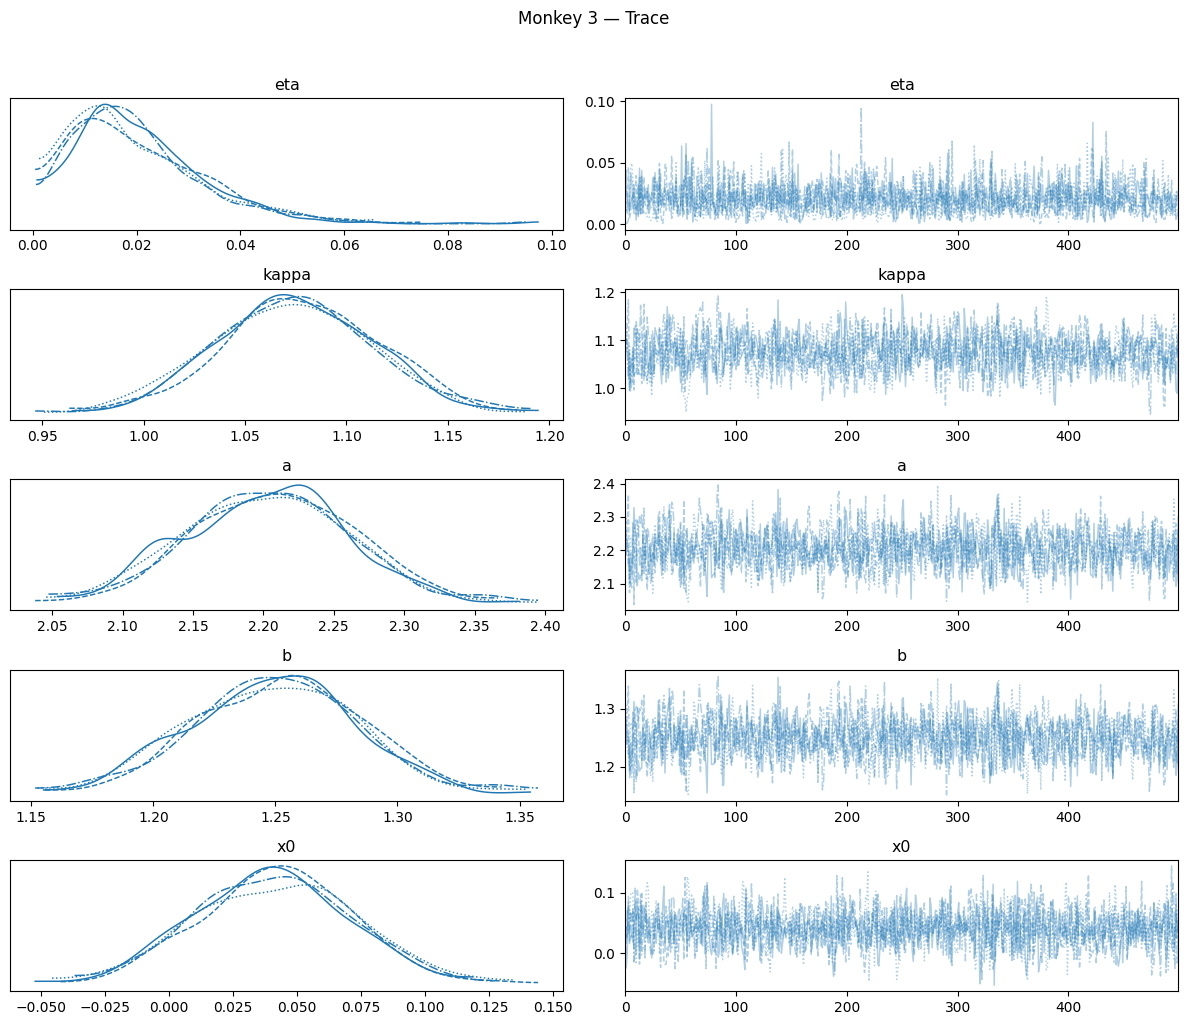

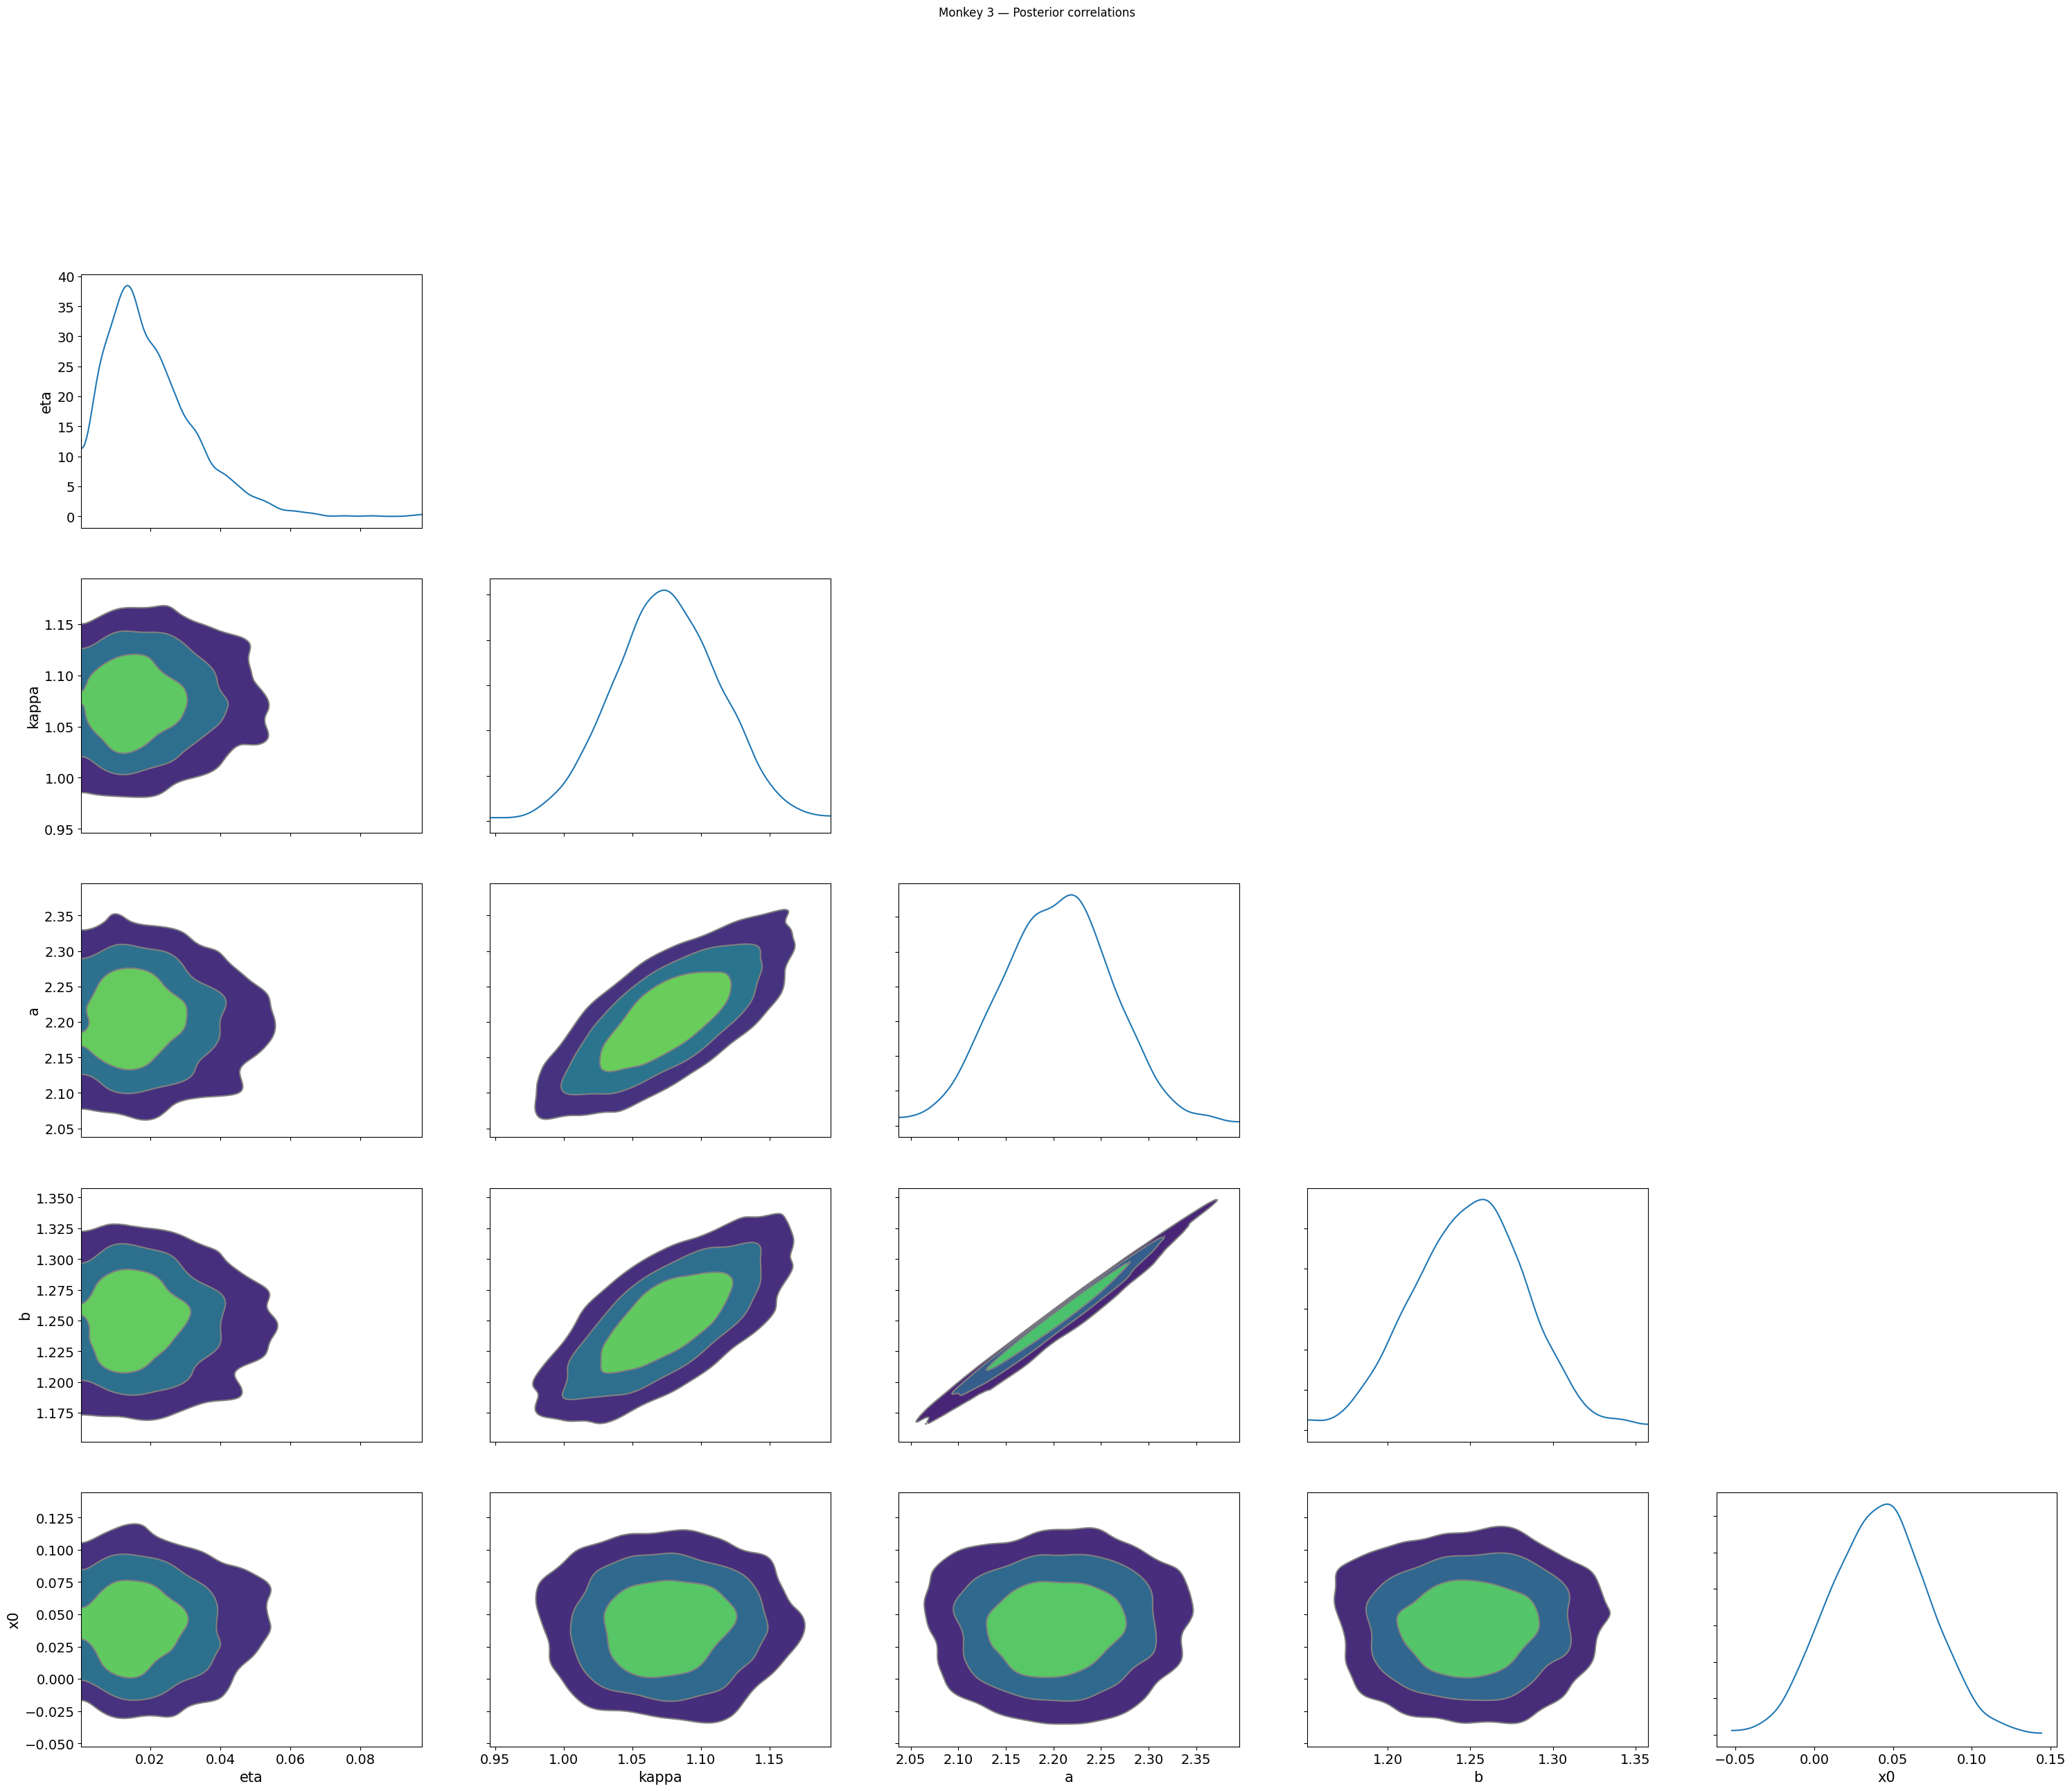

In [21]:
print("=== Monkey 3 Diagnostics ===")
print(az.summary(trace_3, var_names=params))

az.plot_trace(trace_3, var_names=params)
plt.suptitle("Monkey 3 — Trace", y=1.02)
plt.tight_layout()
plt.show()

az.plot_pair(trace_3, var_names=params, kind='kde', marginals=True)
plt.suptitle("Monkey 3 — Posterior correlations", y=1.02)
plt.show()

---
# Save Results

In [ ]:
# Uncomment to save traces
# for idx, trace in enumerate([trace_1, trace_2, trace_3], start=1):
#     trace.to_netcdf(f"empirical_monk{idx}_trace.nc")
#     print(f"Saved monk{idx} trace.")